# Design Routing Policies

In this notebook we're analysing the behaviour of different routing policies

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import random

In [3]:
# fix random seed for reproducibility
random.seed(42)
np.random.seed(42)

## 1) Load Result Dataframe
This section loads the raw results from the file systems `../results/baseline_experiments` folder and extracts the metadata from the file names. The raw results are stored in a dictionary of dataframes, where the key is the subfolder name and filename stem (e.g. "zenbook/boolq_raw_experiment_Llama-3-2-1B-Instruct-ONNX_always_device_once-per-sec_2025-12-03T20-58-00") and the value is the corresponding dataframe. The metadata extracted from the file name is stored in a separate dictionary, where the key is the same as in the raw_dfs and the value is a dictionary containing the device, dataset, model, execution mode and frequency.

In [4]:
from utils import *
import pandas as pd
from pathlib import Path

results_dir = Path('../results/baseline_experiments') # Define root results directory

raw_files = sorted(results_dir.glob('**/*raw*.csv')) # Find all files containing "raw" and ending with .csv in all subdirectories

# Load all raw experiment files into a dictionary of dataframes
raw_dfs = {}
raw_meta = {}  # a dataframe to store the metadata of the experiment extracted from the file name

for file_path in raw_files:
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip() # Strip whitespace from column names

        # Create key: subfolder_name/filename_stem
        relative_path = file_path.relative_to(results_dir)
        key = str(relative_path.parent / relative_path.stem)
        raw_meta[key] = parse_experiment_string(key)
        raw_dfs[key] = df

        print(f"{relative_path} -> shape {df.shape}")
    except Exception as e:
        print(f"[!] Error loading {file_path.name}: {e}")

print(f"\nSUCCESS: Loaded {len(raw_dfs)} raw dataframes")

cloud/ag-news_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-01-31T18-36-02.csv -> shape (500, 22)
cloud/ag-news_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-02-01T12-19-04.csv -> shape (500, 22)
cloud/boolq_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-02-04T09-33-25.csv -> shape (500, 22)
cloud/boolq_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-01-31T19-51-47.csv -> shape (500, 22)
cloud/lorem-ipsum_raw_experiment_meta-llama-llama-3-2_always_cloud_once-per-sec.csv -> shape (201, 22)
cloud/lorem-ipsum_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec.csv -> shape (202, 22)
cloud/spam_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-01-31T17-54-44.csv -> shape (500, 22)
cloud/spam_raw_experiment_openai-gpt-4-1-mini_always_cloud_once-per-sec_2026-02-01T08-09-41.csv -> shape (500, 22)
desktop/ag-news_raw_experiment_Llama-3-2-1B-Instruct-ONNX_

## 2) Deriving an input size based policy (Stateless Threshold Policy)
To find the optimal threshold for input size based routing policy, we run simulations for different arrival times lambda and different thresholds and plot the inference time in dependence of the chosen threshold. The optimal threshold is the global minimum of the curve, as this marks the point with the lowest inference time.

**Limitation of Threshold based Policy:** The scheduler decides only based on input size, not based on system state. In case the dataset is not evenly distributed, it can happen that a lot of jobs are sent to the same system even though it's queue is already exploding and the other system is idling.

In [5]:
from utils import *

df_cloud_ex = raw_dfs['desktop-cloud/boolq_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-02-26T11-11-24'].copy()
df_device_ex = raw_dfs['desktop-device-exp/boolq_lambda7_raw_experiment_Llama-3-2-1B-Instruct-ONNX_always_device_exponential-arrival_2026-02-26T22-47-08'].copy()
# Note: Here we choose a higher arrival rate for on device, as the desktop throttled down execution speed during low demand phases.

name_cloud = "Llama-3-2-1B-Instruct (Open Router)"
name_device = "Llama-3-2-1B-Instruct-ONNX (Desktop PC)"
name_dataset = "BoolQ"

df_device_ex['inference_time_ms'] = (df_device_ex['inference_time_ms'])
df_cloud_ex['inference_time_ms'] = (df_cloud_ex['inference_time_ms'])

--- Llama-3-2-1B-Instruct-ONNX (Desktop PC) ---
Slope: 0.000097 s/char
Intercept: 0.046659 s
R-squared: 0.6876
Std Dev of Residuals (Noise): 0.019267 s


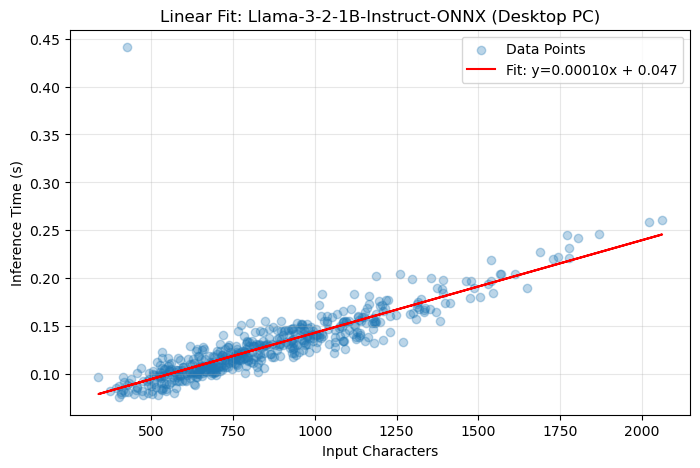

--- Llama-3-2-1B-Instruct (Open Router) ---
Slope: 0.000003 s/char
Intercept: 0.140025 s
R-squared: 0.0002
Std Dev of Residuals (Noise): 0.060533 s


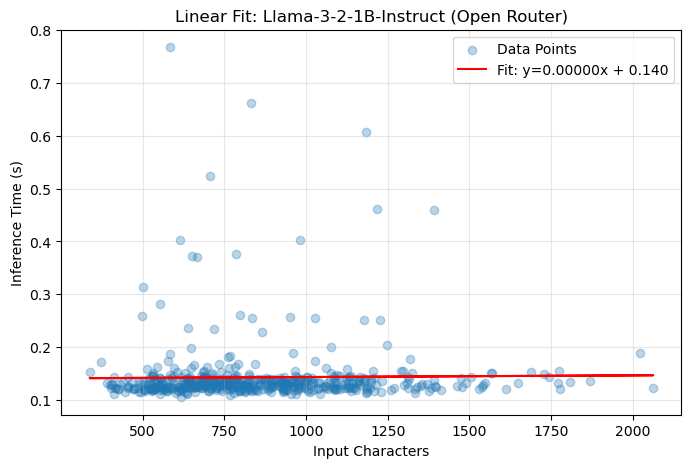


Simulation Params -> Char: (858.5, 296.4)


In [6]:
# Get parameters for Device
slope_dev, int_dev, std_res_dev = estimate_linear_relationship(df_device_ex, name_device)

# Get parameters for Cloud
slope_cloud, int_cloud, std_res_cloud = estimate_linear_relationship(df_cloud_ex, name_cloud)

# Get parameters for Input Character Distribution
char_mean = df_device_ex['number_of_characters'].mean()
char_std = df_device_ex['number_of_characters'].std()

print(f"\nSimulation Params -> Char: ({char_mean:.1f}, {char_std:.1f})")

--- Running simulations for Deterministic Arrivals ($c_{a}=0.0$) ---
  -> Simulating λ = 1.0 req/s
  -> Simulating λ = 2.0 req/s
  -> Simulating λ = 3.0 req/s
  -> Simulating λ = 4.0 req/s
  -> Simulating λ = 5.0 req/s
  -> Simulating λ = 6.0 req/s
  -> Simulating λ = 7.0 req/s
  -> Simulating λ = 8.0 req/s
--- Running simulations for Poisson Arrivals ($c_{a}=1.0$) ---
  -> Simulating λ = 1.0 req/s
  -> Simulating λ = 2.0 req/s
  -> Simulating λ = 3.0 req/s
  -> Simulating λ = 4.0 req/s
  -> Simulating λ = 5.0 req/s
  -> Simulating λ = 6.0 req/s
  -> Simulating λ = 7.0 req/s
  -> Simulating λ = 8.0 req/s
✅ Saved plot: plots/threshold_comparison_20260626T173024.pdf


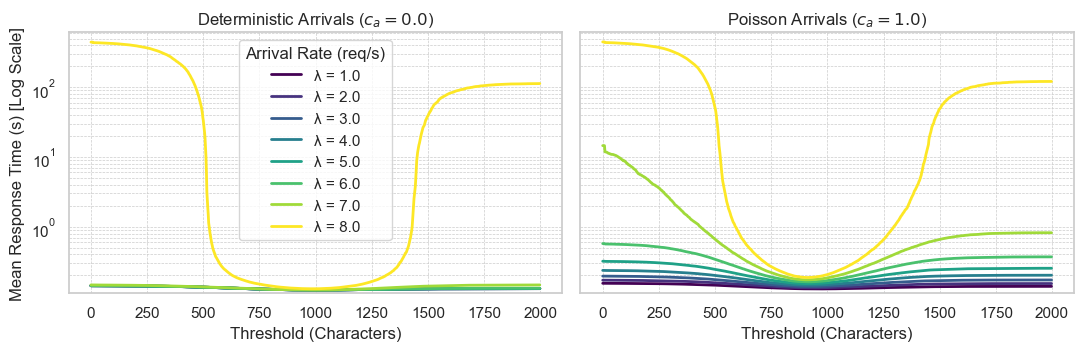

In [12]:
from utils import *

# Define a range of arrival rates to test
test_lambdas = [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0]
thresholds= range(0, 2000, 2)

plot_threshold_comparisons(test_lambdas=test_lambdas,
                           thresholds=thresholds,
                           char_params=(char_mean,char_std),
                           dev_model=(slope_dev, int_dev, std_res_dev),
                           cloud_model=(slope_cloud, int_cloud, std_res_dev))

**how to interpret the analyis plot:**
- X-Axis is the Threshold we set for the routing policy. Any prompt with less characters than T is sent to local device, anything longer goes to the cloud. 
- Y-Axis is the Mean Response Time for the combined system (device and cloud) using the Threshold Policy. It's the weighted weighted average time of requests served by device and cloud.
- The optimal Threshold is the minimum of the curve

## 3) HERO Policy (state-aware) to keep track of queues
Here we want to take the state of the systems (queue length of on-device and cloud) into account. The scheduler is effectively asking: "Including the current backlog, which server will finish this specific job faster?" This is the core principle of the "Join the Shortest Expected Queue" (JSEQ) policy. Combining JSEQ with Thompson Sampling to tune finish-time predictions leads to HERO.

We then plot the inference time against different lambdas and compare it to the base-models and the threshold method.

**Note:** Running the Simulations on local Hardware is rather time consuming. To plot the simulation results in comparison with the experimental verification you can just reuse the completely calculated simulated in `results/policy_simulations`, by setting `RERUN_SIMULATIONS = False`

In [94]:
RERUN_SIMULATIONS =False

### HERO for BoolQ

In [95]:
from utils import *
random.seed(3)

# boolq
df_cloud_ex = raw_dfs['desktop-cloud/boolq_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_once-per-sec_2026-02-26T11-11-24'].copy()
df_device_ex = raw_dfs['desktop-device-exp/boolq_lambda7_raw_experiment_Llama-3-2-1B-Instruct-ONNX_always_device_exponential-arrival_2026-02-26T22-47-08'].copy()

name_cloud = "Llama-3-2-1B-Instruct (Open Router)"
name_device = "Llama-3-2-1B-Instruct-ONNX (Desktop PC)"
device = "Desktop"
name_dataset = "BoolQ"

# Get parameters for Device
slope_dev, int_dev, std_res_dev = estimate_linear_relationship(df_device_ex, name_device, plot=False)

# Get parameters for Cloud
slope_cloud, int_cloud, std_res_cloud = estimate_linear_relationship(df_cloud_ex, name_cloud, plot=False)

# Get parameters for Input Character Distribution
char_mean = df_device_ex['number_of_characters'].mean()
char_std = df_device_ex['number_of_characters'].std()

print(f"\nSimulation Params -> Char: ({char_mean:.1f}, {char_std:.1f})")

--- Llama-3-2-1B-Instruct-ONNX (Desktop PC) ---
Slope: 0.000097 s/char
Intercept: 0.046659 s
R-squared: 0.6876
Std Dev of Residuals (Noise): 0.019267 s
--- Llama-3-2-1B-Instruct (Open Router) ---
Slope: 0.000003 s/char
Intercept: 0.140025 s
R-squared: 0.0002
Std Dev of Residuals (Noise): 0.060533 s

Simulation Params -> Char: (858.5, 296.4)


In [96]:
if RERUN_SIMULATIONS:
    from utils import *
    import pandas as pd
    from pathlib import Path

    test_lambdas = np.linspace(1, 16, 16)
    policies_to_test = ['Always Device ('+name_device+')', 'Always Cloud ('+name_cloud+')', 'Round Robin 2x Device', 'Round Robin 2x Cloud', 'Round Robin (Device/Cloud)', 'Stateless Threshold', 'HERO']
    character_pool = df_device_ex['number_of_characters'].dropna()

    detailed_results = compare_policy_performance_with_table(test_lambdas=test_lambdas,
                                                            policies_to_test=policies_to_test,
                                                            char_params=(char_mean,char_std),
                                                            dev_model=(slope_dev, int_dev, std_res_dev),
                                                            cloud_model=(slope_cloud, int_cloud, std_res_cloud),
                                                            name_device=name_device,
                                                            name_cloud=name_cloud,
                                                            table_and_plot=False,
                                                            num_sim_requests=1000000,
                                                            char_pool=None)
    results_df = pd.DataFrame(detailed_results)

    # Create a clean filename from the model names
    def sanitize_filename(name):
        import re
        name = re.sub(r'\s*\(.*\)\s*', '', name) # Remove parentheses and their contents
        name = re.sub(r'[\s/]+', '_', name) # Replace spaces and slashes with underscores
        name = re.sub(r'[^\w\-_]', '', name) # Remove any remaining non-alphanumeric characters (except underscores and hyphens)
        return name

    clean_device_name = sanitize_filename(name_device)
    clean_cloud_name = sanitize_filename(name_cloud)
    clean_device_hardware = sanitize_filename(device)
    clean_dataset_name = sanitize_filename(name_dataset)
    filename = f'results_{clean_device_name}_on_{clean_device_hardware}_vs_{clean_cloud_name}_for_{clean_dataset_name}.csv'

    # Define the output directory and construct the full file path
    output_dir = Path('../results/policy_simulations')
    output_file = output_dir / filename
    output_dir.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(output_file, index=False)

    print(f"SUCCESS: Saved detailed results to {output_file}")

[SUCCESS]: Loaded data from ../results/policy_simulations/results_Llama-3-2-1B-Instruct-ONNX_on_Desktop_vs_Llama-3-2-1B-Instruct_for_BoolQ.csv
           Found 1050 records and 5 policies to plot.

Loading experimental Always Device results for 'boolq'...
  --- Sanity Check: Always Device Experimental Values ---
    - Lambda: 1.0  -> Avg: 0.2287s, Std: 0.1031s
    - Lambda: 2.0  -> Avg: 0.2110s, Std: 0.0910s
    - Lambda: 3.0  -> Avg: 0.2528s, Std: 0.1527s
    - Lambda: 4.0  -> Avg: 0.2556s, Std: 0.1493s
    - Lambda: 5.0  -> Avg: 0.2932s, Std: 0.1952s
    - Lambda: 6.0  -> Avg: 0.3303s, Std: 0.1804s
    - Lambda: 7.5  -> Avg: 2.1517s, Std: 0.6891s
    - Lambda: 7.0  -> Avg: 0.5345s, Std: 0.2899s
    - Lambda: 7.0  -> Avg: 0.8470s, Std: 0.5393s
  --------------------------------------------

Appended 'Always Device (Experiment)' to policies_to_test.

Loading experimental Always Cloud results for 'boolq'...
  --- Sanity Check: Always Cloud Experimental Values ---
    - Lambda: 1.0  -> A

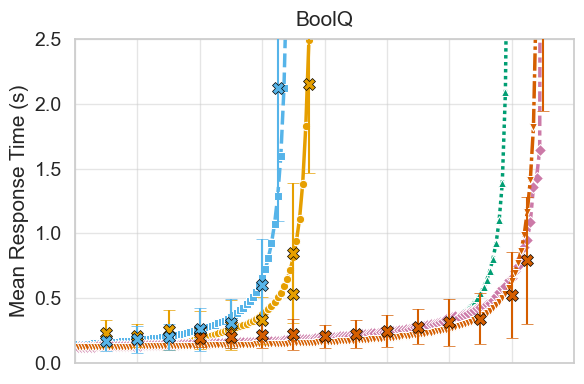

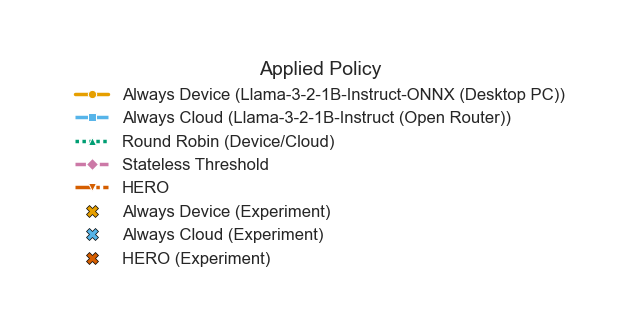

Plot generated successfully.


In [97]:
from utils import *
simulation_file = '../results/policy_simulations/results_Llama-3-2-1B-Instruct-ONNX_on_Desktop_vs_Llama-3-2-1B-Instruct_for_BoolQ.csv'
load_and_plot_policy_results(simulation_file, augment_with_jseq=True, augment_with_baseline=True, dataset_name_for_exp='boolq', dataset_name_title='BoolQ',show_x_axis=False)

### HERO for Spam/Ham 

In [98]:
from utils import *

# spam
df_cloud_ex = raw_dfs['desktop-cloud-exp/spam_lambda4_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_exponential-arrival_2026-02-28T11-32-01'].copy()
df_device_ex = raw_dfs['desktop-device-exp/spam_lambda2_raw_experiment_Llama-3-2-1B-Instruct-ONNX_always_device_exponential-arrival_2026-02-28T12-38-41'].copy()

name_cloud = "Llama-3-2-1B-Instruct (Open Router)"
name_device = "Llama-3-2-1B-Instruct-ONNX (Desktop PC)"
device = "Desktop"
name_dataset = "Spam"



# Get parameters for Device
slope_dev, int_dev, std_res_dev = estimate_linear_relationship(df_device_ex, name_device, plot=False)

# Get parameters for Cloud
slope_cloud, int_cloud, std_res_cloud = estimate_linear_relationship(df_cloud_ex, name_cloud, plot=False)

# Get parameters for Input Character Distribution
char_mean = df_device_ex['number_of_characters'].mean()
char_std = df_device_ex['number_of_characters'].std()

print(f"\nSimulation Params -> Char: ({char_mean:.1f}, {char_std:.1f})")

--- Llama-3-2-1B-Instruct-ONNX (Desktop PC) ---
Slope: 0.000173 s/char
Intercept: -0.008040 s
R-squared: 0.9243
Std Dev of Residuals (Noise): 0.074331 s
--- Llama-3-2-1B-Instruct (Open Router) ---
Slope: 0.000008 s/char
Intercept: 0.119620 s
R-squared: 0.1022
Std Dev of Residuals (Noise): 0.033911 s

Simulation Params -> Char: (1710.1, 1498.4)


In [99]:
if RERUN_SIMULATIONS:
    from utils import *
    import pandas as pd
    from pathlib import Path

    test_lambdas = np.linspace(0.1, 14, 140)

    policies_to_test = ['Always Device ('+name_device+')', 'Always Cloud ('+name_cloud+')', 'Round Robin 2x Device', 'Round Robin 2x Cloud', 'Round Robin (Device/Cloud)', 'Stateless Threshold', 'HERO']
    

    detailed_results = compare_policy_performance_with_table(test_lambdas=test_lambdas,
                                                            policies_to_test=policies_to_test,
                                                            char_params=(char_mean,char_std),
                                                            dev_model=(slope_dev, int_dev, std_res_dev),
                                                            cloud_model=(slope_cloud, int_cloud, std_res_dev),
                                                            name_device=name_device,
                                                            name_cloud=name_cloud,
                                                            table_and_plot=False,
                                                            num_sim_requests=500000)
    results_df = pd.DataFrame(detailed_results)

    # Create a clean filename from the model names
    def sanitize_filename(name):
        import re
        name = re.sub(r'\s*\(.*\)\s*', '', name) # Remove parentheses and their contents
        name = re.sub(r'[\s/]+', '_', name) # Replace spaces and slashes with underscores
        name = re.sub(r'[^\w\-_]', '', name) # Remove any remaining non-alphanumeric characters (except underscores and hyphens)
        return name

    clean_device_name = sanitize_filename(name_device)
    clean_cloud_name = sanitize_filename(name_cloud)
    clean_device_hardware = sanitize_filename(device)
    clean_dataset_name = sanitize_filename(name_dataset)
    filename = f'results_{clean_device_name}_on_{clean_device_hardware}_vs_{clean_cloud_name}_for_{clean_dataset_name}.csv'

    # Define the output directory and construct the full file path
    output_dir = Path('../results/policy_simulations')
    output_file = output_dir / filename
    output_dir.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(output_file, index=False)

    print(f"SUCCESS: Saved detailed results to {output_file}")

[SUCCESS]: Loaded data from ../results/policy_simulations/results_Llama-3-2-1B-Instruct-ONNX_on_Desktop_vs_Llama-3-2-1B-Instruct_for_Spam.csv
           Found 980 records and 5 policies to plot.

Loading experimental Always Device results for 'spam'...
  --- Sanity Check: Always Device Experimental Values ---
    - Lambda: 1.0  -> Avg: 0.4637s, Std: 0.4399s
    - Lambda: 2.0  -> Avg: 0.5516s, Std: 0.4626s
    - Lambda: 3.0  -> Avg: 1.4047s, Std: 1.2931s
  --------------------------------------------

Appended 'Always Device (Experiment)' to policies_to_test.

Loading experimental Always Cloud results for 'spam'...
  --- Sanity Check: Always Cloud Experimental Values ---
    - Lambda: 1.0  -> Avg: 0.1697s, Std: 0.0814s
    - Lambda: 2.0  -> Avg: 0.1857s, Std: 0.1092s
    - Lambda: 3.0  -> Avg: 0.2372s, Std: 0.1533s
    - Lambda: 4.0  -> Avg: 0.2749s, Std: 0.1608s
    - Lambda: 5.0  -> Avg: 0.3365s, Std: 0.2468s
    - Lambda: 6.0  -> Avg: 0.5076s, Std: 0.3892s
    - Lambda: 7.0  -> Avg: 

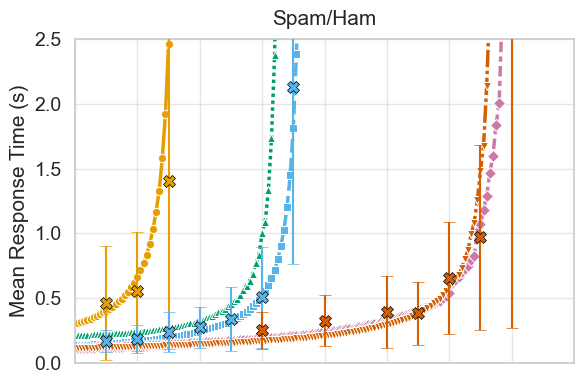

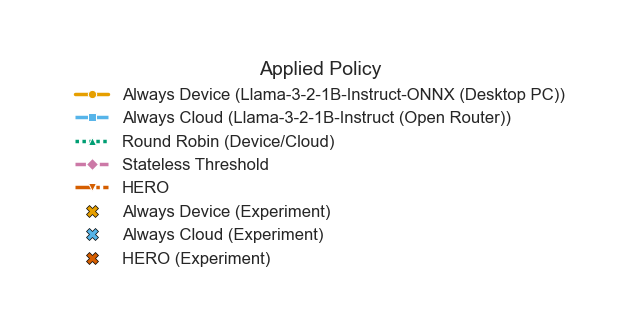

Plot generated successfully.


In [100]:
from utils import *
simulation_file = '../results/policy_simulations/results_Llama-3-2-1B-Instruct-ONNX_on_Desktop_vs_Llama-3-2-1B-Instruct_for_Spam.csv'
load_and_plot_policy_results(simulation_file, augment_with_jseq=True, augment_with_baseline=True, dataset_name_for_exp='spam', dataset_name_title='Spam/Ham', show_x_axis=False)

### HERO for AG News

In [101]:
from utils import *

# agnews
df_cloud_ex = raw_dfs['desktop-cloud-exp/ag-news_lambda2_raw_experiment_meta-llama-llama-3-2-1b-instruct_always_cloud_exponential-arrival_2026-02-28T10-43-09'].copy()
df_device_ex = raw_dfs['desktop-device-exp/ag-news_lambda5_raw_experiment_Llama-3-2-1B-Instruct-ONNX_always_device_exponential-arrival_2026-02-28T10-31-08'].copy()


name_cloud = "Llama-3-2-1B-Instruct (Open Router)"
name_device = "Llama-3-2-1B-Instruct-ONNX (Desktop PC)"
device = "Desktop"
name_dataset = "agnews"

# Get parameters for Device
slope_dev, int_dev, std_res_dev = estimate_linear_relationship(df_device_ex, name_device, plot=False)

# Get parameters for Cloud
slope_cloud, int_cloud, std_res_cloud = estimate_linear_relationship(df_cloud_ex, name_cloud, plot=False)

# Get parameters for Input Character Distribution
char_mean = df_device_ex['number_of_characters'].mean()
char_std = df_device_ex['number_of_characters'].std()

print(f"\nSimulation Params -> Char: ({char_mean:.1f}, {char_std:.1f})")

--- Llama-3-2-1B-Instruct-ONNX (Desktop PC) ---
Slope: 0.000097 s/char
Intercept: 0.053815 s
R-squared: 0.0839
Std Dev of Residuals (Noise): 0.021306 s
--- Llama-3-2-1B-Instruct (Open Router) ---
Slope: 0.000006 s/char
Intercept: 0.126522 s
R-squared: 0.0001
Std Dev of Residuals (Noise): 0.046997 s

Simulation Params -> Char: (755.9, 66.6)


In [102]:
if RERUN_SIMULATIONS:
    from utils import *
    import pandas as pd
    from pathlib import Path
    
    test_lambdas = np.linspace(1, 16, 16)

    policies_to_test = ['Always Device ('+name_device+')', 'Always Cloud ('+name_cloud+')', 'Round Robin 2x Device', 'Round Robin 2x Cloud', 'Round Robin (Device/Cloud)', 'Stateless Threshold', 'HERO']


    detailed_results = compare_policy_performance_with_table(test_lambdas=test_lambdas,
                                                            policies_to_test=policies_to_test,
                                                            char_params=(char_mean,char_std),
                                                            dev_model=(slope_dev, int_dev, std_res_dev),
                                                            cloud_model=(slope_cloud, int_cloud, std_res_cloud),
                                                            name_device=name_device,
                                                            name_cloud=name_cloud,
                                                            table_and_plot=False,
                                                            num_sim_requests=500000)
    results_df = pd.DataFrame(detailed_results)

    # Create a clean filename from the model names
    def sanitize_filename(name):
        import re
        name = re.sub(r'\s*\(.*\)\s*', '', name) # Remove parentheses and their contents
        name = re.sub(r'[\s/]+', '_', name) # Replace spaces and slashes with underscores
        name = re.sub(r'[^\w\-_]', '', name) # Remove any remaining non-alphanumeric characters (except underscores and hyphens)
        return name

    clean_device_name = sanitize_filename(name_device)
    clean_cloud_name = sanitize_filename(name_cloud)
    clean_device_hardware = sanitize_filename(device)
    clean_dataset_name = sanitize_filename(name_dataset)
    filename = f'results_{clean_device_name}_on_{clean_device_hardware}_vs_{clean_cloud_name}_for_{clean_dataset_name}.csv'

    # Define the output directory and construct the full file path
    output_dir = Path('../results/policy_simulations')
    output_file = output_dir / filename
    output_dir.mkdir(parents=True, exist_ok=True)
    results_df.to_csv(output_file, index=False)

    print(f"SUCCESS: Saved detailed results to {output_file}")

[SUCCESS]: Loaded data from ../results/policy_simulations/results_Llama-3-2-1B-Instruct-ONNX_on_Desktop_vs_Llama-3-2-1B-Instruct_for_agnews.csv
           Found 1260 records and 5 policies to plot.

Loading experimental Always Device results for 'ag-news'...
  --- Sanity Check: Always Device Experimental Values ---
    - Lambda: 2.0  -> Avg: 0.2104s, Std: 0.0772s
    - Lambda: 4.0  -> Avg: 0.2225s, Std: 0.0960s
    - Lambda: 5.0  -> Avg: 0.2460s, Std: 0.1382s
    - Lambda: 6.0  -> Avg: 0.3313s, Std: 0.2249s
    - Lambda: 7.0  -> Avg: 0.5351s, Std: 0.2935s
    - Lambda: 8.0  -> Avg: 1.6562s, Std: 0.7816s
  --------------------------------------------

Appended 'Always Device (Experiment)' to policies_to_test.

Loading experimental Always Cloud results for 'ag-news'...
  --- Sanity Check: Always Cloud Experimental Values ---
    - Lambda: 2.0  -> Avg: 0.1713s, Std: 0.0883s
    - Lambda: 4.0  -> Avg: 0.3517s, Std: 0.2673s
    - Lambda: 5.0  -> Avg: 0.3426s, Std: 0.2633s
    - Lambda: 6.0 

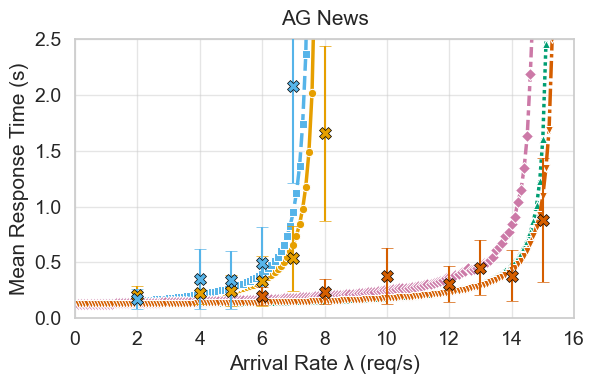

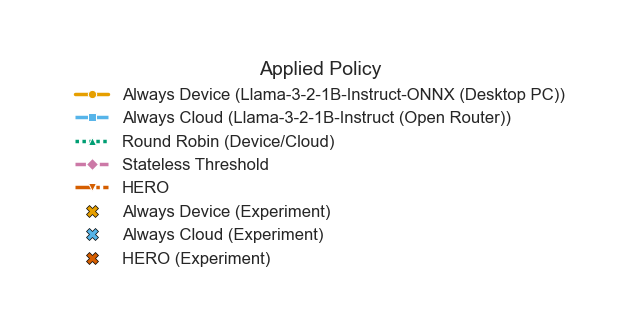

Plot generated successfully.


In [103]:
from utils import *
simulation_file = '../results/policy_simulations/results_Llama-3-2-1B-Instruct-ONNX_on_Desktop_vs_Llama-3-2-1B-Instruct_for_agnews.csv'
load_and_plot_policy_results(simulation_file, augment_with_jseq=True, augment_with_baseline=True, dataset_name_for_exp='ag-news', dataset_name_title='AG-News', show_x_axis=True)